## S30的趋势强度

In [40]:
import polars as pl
import numpy as np
import pandas as pd

In [41]:
data=pl.read_parquet("/home/zyli/yinzi/klines/30s.parquet")
data=data.filter(pl.col("exch")!="CFFEX")
data=data.with_columns(
    (pl.col("opn")*pl.col("adjf")).alias("open"),
    (pl.col("hgh")*pl.col("adjf")).alias("high"),
    (pl.col("low")*pl.col("adjf")).alias("low"),
    (pl.col("cls")*pl.col("adjf")).alias("close"),
    (pl.col("vwap")*pl.col("adjf")).alias("vwap"),
    (pl.col("samp_ts").dt.offset_by("8h")).alias("samp_ts")
)


# data=data.select(["d","samp_ts","udl","open","high","low","close","vwap","trd_vol","total_vol"])
data=data.sort(["udl","d","samp_ts"])

data

sys:1: CategoricalRemappingWarning: Local categoricals have different encodings, expensive re-encoding is done to perform this merge operation. Consider using a StringCache or an Enum type if the categories are known in advance


d,samp_ts,udl,sym,exch,expd,multi,tick_size,opn,hgh,low,cls,vwap,twap,trd_vol,trd_amt,total_vol,total_amt,oi,adjf,open,high,close
u32,datetime[ms],cat,cat,cat,u16,u16,f64,f64,f64,f64,f64,f64,f64,i64,i64,u32,u64,u32,f64,f64,f64,f64
20220901,2022-08-31 21:00:30,"""eg""","""eg2301""","""DCE""",141,10,1.0,4025.0,4053.0,3694.214738,4051.0,3710.643292,4044.302521,5846,236347910,9566,386096720,375231,0.917817,3694.214738,3719.913624,3718.077989
20220901,2022-08-31 21:01:00,"""eg""","""eg2301""","""DCE""",141,10,1.0,4052.0,4052.0,3707.981998,4041.0,3712.323775,4043.558333,2917,117984790,12488,504284110,375512,0.917817,3718.995806,3718.995806,3708.899816
20220901,2022-08-31 21:01:30,"""eg""","""eg2301""","""DCE""",141,10,1.0,4042.0,4047.0,3708.899816,4045.0,3711.470931,4043.798319,2094,84677200,14589,589244190,375792,0.917817,3709.817633,3714.40672,3712.571085
20220901,2022-08-31 21:02:00,"""eg""","""eg2301""","""DCE""",141,10,1.0,4045.0,4045.0,3707.064181,4039.0,3708.467328,4040.558333,1789,72285060,16380,661610140,375941,0.917817,3712.571085,3712.571085,3707.064181
20220901,2022-08-31 21:02:30,"""eg""","""eg2301""","""DCE""",141,10,1.0,4039.0,4049.0,3706.146364,4048.0,3710.456559,4042.942149,1527,61731970,17909,723422900,375945,0.917817,3707.064181,3716.242354,3715.324537
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
20240628,2024-06-28 14:58:00,"""PX""","""PX409""","""CZCE""",78,5,2.0,8658.0,8660.0,8404.542256,8656.0,8405.90532,8657.217391,104,4501850,59265,2561327240,84946,0.97095,8406.484156,8408.426056,8404.542256
20240628,2024-06-28 14:58:30,"""PX""","""PX409""","""CZCE""",78,5,2.0,8656.0,8660.0,8402.600356,8656.0,8404.309892,8657.0,234,10127240,59499,2571454480,84946,0.97095,8404.542256,8408.426056,8404.542256
20240628,2024-06-28 14:59:00,"""PX""","""PX409""","""CZCE""",78,5,2.0,8654.0,8656.0,8396.774657,8654.0,8400.836901,8653.375,185,8003270,59686,2579544290,84838,0.97095,8402.600356,8404.542256,8402.600356


In [42]:
data=data.with_columns(
    (pl.col("close")-pl.col("close").shift(120)).over("udl").alias("Weiyi"),
    abs(pl.col("close")-pl.col("close").shift(1)).over("udl").alias("single_length")
)
data=data.with_columns(
    pl.col("single_length").rolling_sum(window_size=120,min_samples=120).over("udl").alias("lucheng")
)

data=data.drop_nulls()
# data=data.fill_null(0)

data

d,samp_ts,udl,sym,exch,expd,multi,tick_size,opn,hgh,low,cls,vwap,twap,trd_vol,trd_amt,total_vol,total_amt,oi,adjf,open,high,close,Weiyi,single_length,lucheng
u32,datetime[ms],cat,cat,cat,u16,u16,f64,f64,f64,f64,f64,f64,f64,i64,i64,u32,u64,u32,f64,f64,f64,f64,f64,f64,f64
20220901,2022-08-31 22:00:30,"""eg""","""eg2301""","""DCE""",141,10,1.0,4054.0,4055.0,3716.242354,4049.0,3718.90887,4052.263158,1288,52188540,76315,3094776750,377034,0.917817,3720.831441,3721.749258,3716.242354,-1.835635,4.589087,242.303774
20220901,2022-08-31 22:01:00,"""eg""","""eg2301""","""DCE""",141,10,1.0,4049.0,4051.0,3714.40672,4049.0,3716.0129,4048.974359,680,27531500,77003,3122632200,377050,0.917817,3716.242354,3718.077989,3716.242354,7.342539,0.0,233.125601
20220901,2022-08-31 22:01:30,"""eg""","""eg2301""","""DCE""",141,10,1.0,4050.0,4052.0,3715.324537,4051.0,3717.681361,4050.605042,560,22683180,77575,3145801380,377060,0.917817,3717.160172,3718.995806,3718.077989,5.506904,1.835635,231.289966
20220901,2022-08-31 22:02:00,"""eg""","""eg2301""","""DCE""",141,10,1.0,4051.0,4053.0,3717.160172,4053.0,3718.364153,4051.431193,263,10654950,77846,3156780410,377065,0.917817,3718.077989,3719.913624,3719.913624,12.849443,1.835635,227.618697
20220901,2022-08-31 22:02:30,"""eg""","""eg2301""","""DCE""",141,10,1.0,4053.0,4054.0,3718.995806,4054.0,3719.933235,4053.227273,468,18968140,78314,3175748550,377057,0.917817,3719.913624,3720.831441,3720.831441,5.506904,0.917817,220.276158
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
20240628,2024-06-28 14:58:00,"""PX""","""PX409""","""CZCE""",78,5,2.0,8658.0,8660.0,8404.542256,8656.0,8405.90532,8657.217391,104,4501850,59265,2561327240,84946,0.97095,8406.484156,8408.426056,8404.542256,-5.825699,1.9419,184.480479
20240628,2024-06-28 14:58:30,"""PX""","""PX409""","""CZCE""",78,5,2.0,8656.0,8660.0,8402.600356,8656.0,8404.309892,8657.0,234,10127240,59499,2571454480,84946,0.97095,8404.542256,8408.426056,8404.542256,-5.825699,0.0,184.480479
20240628,2024-06-28 14:59:00,"""PX""","""PX409""","""CZCE""",78,5,2.0,8654.0,8656.0,8396.774657,8654.0,8400.836901,8653.375,185,8003270,59686,2579544290,84838,0.97095,8402.600356,8404.542256,8402.600356,-7.767599,1.9419,186.422379


In [43]:
# data=data.drop_nulls()

In [44]:
# data=data.with_columns(
#     pl.col("single_length").rolling_sum(window_size=120,min_samples=1).over("udl").alias("lucheng")
# )

# data

In [45]:
data=data.with_columns(
    (pl.col("Weiyi")/pl.col("lucheng")).alias("factor")
)

data

d,samp_ts,udl,sym,exch,expd,multi,tick_size,opn,hgh,low,cls,vwap,twap,trd_vol,trd_amt,total_vol,total_amt,oi,adjf,open,high,close,Weiyi,single_length,lucheng,factor
u32,datetime[ms],cat,cat,cat,u16,u16,f64,f64,f64,f64,f64,f64,f64,i64,i64,u32,u64,u32,f64,f64,f64,f64,f64,f64,f64,f64
20220901,2022-08-31 22:00:30,"""eg""","""eg2301""","""DCE""",141,10,1.0,4054.0,4055.0,3716.242354,4049.0,3718.90887,4052.263158,1288,52188540,76315,3094776750,377034,0.917817,3720.831441,3721.749258,3716.242354,-1.835635,4.589087,242.303774,-0.007576
20220901,2022-08-31 22:01:00,"""eg""","""eg2301""","""DCE""",141,10,1.0,4049.0,4051.0,3714.40672,4049.0,3716.0129,4048.974359,680,27531500,77003,3122632200,377050,0.917817,3716.242354,3718.077989,3716.242354,7.342539,0.0,233.125601,0.031496
20220901,2022-08-31 22:01:30,"""eg""","""eg2301""","""DCE""",141,10,1.0,4050.0,4052.0,3715.324537,4051.0,3717.681361,4050.605042,560,22683180,77575,3145801380,377060,0.917817,3717.160172,3718.995806,3718.077989,5.506904,1.835635,231.289966,0.02381
20220901,2022-08-31 22:02:00,"""eg""","""eg2301""","""DCE""",141,10,1.0,4051.0,4053.0,3717.160172,4053.0,3718.364153,4051.431193,263,10654950,77846,3156780410,377065,0.917817,3718.077989,3719.913624,3719.913624,12.849443,1.835635,227.618697,0.056452
20220901,2022-08-31 22:02:30,"""eg""","""eg2301""","""DCE""",141,10,1.0,4053.0,4054.0,3718.995806,4054.0,3719.933235,4053.227273,468,18968140,78314,3175748550,377057,0.917817,3719.913624,3720.831441,3720.831441,5.506904,0.917817,220.276158,0.025
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
20240628,2024-06-28 14:58:00,"""PX""","""PX409""","""CZCE""",78,5,2.0,8658.0,8660.0,8404.542256,8656.0,8405.90532,8657.217391,104,4501850,59265,2561327240,84946,0.97095,8406.484156,8408.426056,8404.542256,-5.825699,1.9419,184.480479,-0.031579
20240628,2024-06-28 14:58:30,"""PX""","""PX409""","""CZCE""",78,5,2.0,8656.0,8660.0,8402.600356,8656.0,8404.309892,8657.0,234,10127240,59499,2571454480,84946,0.97095,8404.542256,8408.426056,8404.542256,-5.825699,0.0,184.480479,-0.031579
20240628,2024-06-28 14:59:00,"""PX""","""PX409""","""CZCE""",78,5,2.0,8654.0,8656.0,8396.774657,8654.0,8400.836901,8653.375,185,8003270,59686,2579544290,84838,0.97095,8402.600356,8404.542256,8402.600356,-7.767599,1.9419,186.422379,-0.041667


In [46]:
data=data.with_columns(
    ((pl.col("close").shift(-1)/pl.col("close"))-1).over("udl").alias("label1"),
    ((pl.col("close").shift(-121)/pl.col("close"))-1).over("udl").alias("label60")
)

# data=data.fill_null(0)
data=data.drop_nulls()

data

d,samp_ts,udl,sym,exch,expd,multi,tick_size,opn,hgh,low,cls,vwap,twap,trd_vol,trd_amt,total_vol,total_amt,oi,adjf,open,high,close,Weiyi,single_length,lucheng,factor,label1,label60
u32,datetime[ms],cat,cat,cat,u16,u16,f64,f64,f64,f64,f64,f64,f64,i64,i64,u32,u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
20220901,2022-08-31 22:00:30,"""eg""","""eg2301""","""DCE""",141,10,1.0,4054.0,4055.0,3716.242354,4049.0,3718.90887,4052.263158,1288,52188540,76315,3094776750,377034,0.917817,3720.831441,3721.749258,3716.242354,-1.835635,4.589087,242.303774,-0.007576,0.0,0.002223
20220901,2022-08-31 22:01:00,"""eg""","""eg2301""","""DCE""",141,10,1.0,4049.0,4051.0,3714.40672,4049.0,3716.0129,4048.974359,680,27531500,77003,3122632200,377050,0.917817,3716.242354,3718.077989,3716.242354,7.342539,0.0,233.125601,0.031496,0.000494,0.001729
20220901,2022-08-31 22:01:30,"""eg""","""eg2301""","""DCE""",141,10,1.0,4050.0,4052.0,3715.324537,4051.0,3717.681361,4050.605042,560,22683180,77575,3145801380,377060,0.917817,3717.160172,3718.995806,3718.077989,5.506904,1.835635,231.289966,0.02381,0.000494,0.001728
20220901,2022-08-31 22:02:00,"""eg""","""eg2301""","""DCE""",141,10,1.0,4051.0,4053.0,3717.160172,4053.0,3718.364153,4051.431193,263,10654950,77846,3156780410,377065,0.917817,3718.077989,3719.913624,3719.913624,12.849443,1.835635,227.618697,0.056452,0.000247,0.00148
20220901,2022-08-31 22:02:30,"""eg""","""eg2301""","""DCE""",141,10,1.0,4053.0,4054.0,3718.995806,4054.0,3719.933235,4053.227273,468,18968140,78314,3175748550,377057,0.917817,3719.913624,3720.831441,3720.831441,5.506904,0.917817,220.276158,0.025,-0.000493,0.001727
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
20240628,2024-06-28 13:57:00,"""PX""","""PX409""","""CZCE""",78,5,2.0,8664.0,8664.0,8410.367955,8664.0,8410.721028,8663.454545,11,476430,52453,2266329770,85404,0.97095,8412.309855,8412.309855,8412.309855,17.477098,0.0,200.015678,0.087379,-0.000231,-0.000923
20240628,2024-06-28 13:57:30,"""PX""","""PX409""","""CZCE""",78,5,2.0,8662.0,8662.0,8408.426056,8662.0,8409.073355,8661.272727,9,389730,52464,2266806120,85404,0.97095,8410.367955,8410.367955,8410.367955,17.477098,1.9419,200.015678,0.087379,0.0,-0.000693
20240628,2024-06-28 13:58:00,"""PX""","""PX409""","""CZCE""",78,5,2.0,8662.0,8662.0,8410.367955,8662.0,8410.367955,8662.0,4,173240,52468,2266979360,85400,0.97095,8410.367955,8410.367955,8410.367955,17.477098,0.0,200.015678,0.087379,0.0,-0.000924


In [47]:
data=data.select(["samp_ts","d","udl","factor","label1","label60"])
data=data.drop_nans()
data

samp_ts,d,udl,factor,label1,label60
datetime[ms],u32,cat,f64,f64,f64
2022-08-31 22:00:30,20220901,"""eg""",-0.007576,0.0,0.002223
2022-08-31 22:01:00,20220901,"""eg""",0.031496,0.000494,0.001729
2022-08-31 22:01:30,20220901,"""eg""",0.02381,0.000494,0.001728
2022-08-31 22:02:00,20220901,"""eg""",0.056452,0.000247,0.00148
2022-08-31 22:02:30,20220901,"""eg""",0.025,-0.000493,0.001727
…,…,…,…,…,…
2024-06-28 13:57:00,20240628,"""PX""",0.087379,-0.000231,-0.000923
2024-06-28 13:57:30,20240628,"""PX""",0.087379,0.0,-0.000693
2024-06-28 13:58:00,20240628,"""PX""",0.087379,0.0,-0.000924


In [48]:
data=data.with_columns(
    (pl.col("factor").ewm_mean(alpha=0.1,min_samples=1).over("udl")).alias("factor")
)

data=data.with_columns(
    (pl.col("factor").ewm_mean(alpha=0.1,min_samples=1).over("udl")).alias("factor")
)



In [49]:
# 假设您已经有一个包含所需列的polars DataFrame: df
# df应包含: samp_ts, d, udl, factor, label1, label60

# 转换为pandas进行计算（保持与您原代码一致的计算方式）
df_pd = data.to_pandas()

# 计算总体IC
overall_ic = df_pd['factor'].corr(df_pd['label60']) * 100

# 计算换手率
n_symbols = len(df_pd['udl'].unique())
mtvr = df_pd['factor'].diff().abs().sum() / n_symbols / 440

# 添加年份列
df_pd['year'] = pd.to_datetime(df_pd['samp_ts']).dt.year

# 计算年度IC
yearly_ic = df_pd.groupby('year')[['factor', 'label60']].corr().unstack()['label60']['factor'] * 100

print(f"all ic: {overall_ic:.4f}, mtvr: {mtvr:.6f}")
yearly_ic

all ic: 0.5011, mtvr: 1.197208


year
2022    0.696627
2023    1.203730
2024   -1.209082
Name: factor, dtype: float64

In [50]:
# Min-Max缩放到[-1,1]区间
data = data.with_columns(
    (2 * (pl.col("factor") - pl.col("factor").min().over("udl")) / 
     (pl.col("factor").max().over("udl") - pl.col("factor").min().over("udl") + 1e-10) - 1)
    .alias("factor")
)

In [51]:
data

samp_ts,d,udl,factor,label1,label60
datetime[ms],u32,cat,f64,f64,f64
2022-08-31 22:00:30,20220901,"""eg""",0.017134,0.0,0.002223
2022-08-31 22:01:00,20220901,"""eg""",0.046589,0.000494,0.001729
2022-08-31 22:01:30,20220901,"""eg""",0.060381,0.000494,0.001728
2022-08-31 22:02:00,20220901,"""eg""",0.076322,0.000247,0.00148
2022-08-31 22:02:30,20220901,"""eg""",0.085255,-0.000493,0.001727
…,…,…,…,…,…
2024-06-28 13:57:00,20240628,"""PX""",0.333869,-0.000231,-0.000923
2024-06-28 13:57:30,20240628,"""PX""",0.332468,0.0,-0.000693
2024-06-28 13:58:00,20240628,"""PX""",0.331442,0.0,-0.000924


In [52]:
# 第一步：计算单期边际收益
data = data.with_columns(
    (pl.col("factor") * pl.col("label1").shift(-1).over("udl")).alias("margin_return")
)

data=data.fill_null(0)

# 第二步：计算累积边际收益
data = data.with_columns(
    pl.col("margin_return").cum_sum().over("udl").alias("cumulative_return")
)

# 第三步：先创建 position_change 列（相当于您代码中的abs_diff）
data = data.with_columns(
    pl.col("factor").diff().abs().over("udl").alias("position_change")
)

# 第四步：再使用 position_change 列计算 cumulative_turnover
data = data.with_columns(
    pl.col("position_change").cum_sum().over("udl").alias("cumulative_turnover")
)

# 获取每个品种最后一行的数据（相当于您代码中的last()）
final_stats = data.group_by("udl").agg(
    pl.col("cumulative_return").last().alias("ret"),
    pl.col("cumulative_turnover").last().alias("abs_diff")
)

# 计算ret/abs_diff（相当于您代码中的ret/abs_diff）
final_stats = final_stats.with_columns(
    (pl.col("ret") / pl.col("abs_diff") * 10000).alias("ret_per_turnover")
)

# 按ret降序排序
sorted_stats = final_stats.sort("ret", descending=True)

# 计算ret/abs_diff的平均值
avg_ret_per_turnover = final_stats.select(pl.mean("ret_per_turnover")).item()

# 输出结果
print(f"平均每单位换手收益率（×10000）: {avg_ret_per_turnover}")

# 返回排序后的结果
sorted_stats

平均每单位换手收益率（×10000）: 0.1956783868303245


udl,ret,abs_diff,ret_per_turnover
cat,f64,f64,f64
"""pg""",0.181673,1203.728122,1.509256
"""ag""",0.167787,1721.545796,0.974629
"""OI""",0.156539,1249.308842,1.253006
"""sp""",0.155996,1169.153564,1.334263
"""ru""",0.151448,1108.408811,1.366353
…,…,…,…
"""PX""",-0.074003,554.21584,-1.335277
"""ao""",-0.08834,810.683749,-1.089704
"""nr""",-0.102408,1218.045603,-0.840754


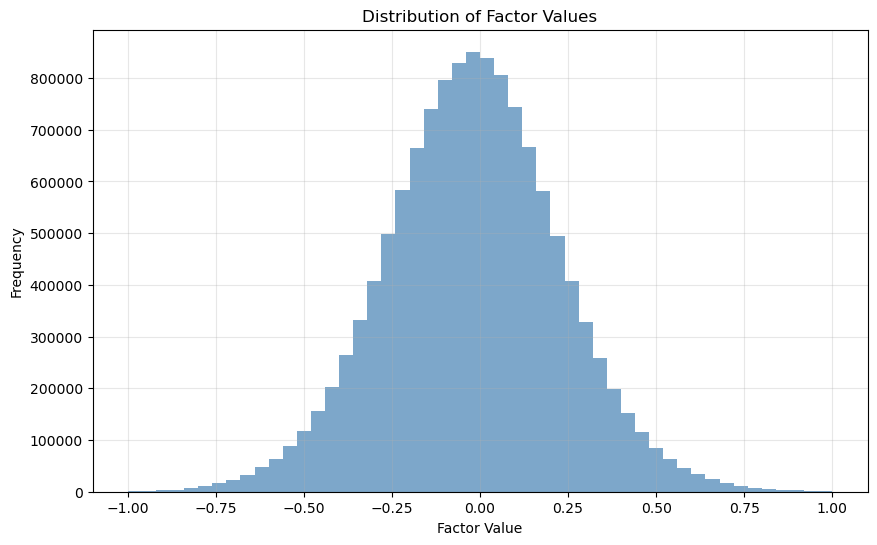

In [53]:
import matplotlib.pyplot as plt

# 绘制factor的分布图
plt.figure(figsize=(10, 6))
plt.hist(data['factor'].to_numpy(), bins=50, color='steelblue', alpha=0.7)
plt.title('Distribution of Factor Values')
plt.xlabel('Factor Value')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()